# 01 – Data Understanding
Ziel: Rohdaten kennenlernen, Qualität prüfen, erste Plots.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('.C:\\Users\\felix\\Downloads\\Daten zur Windkennlinie_2025-09-17\\Schwanfeld\\2016_10-Min-Daten WEA Schwanfeld.xlsx.')

from src.data.load_data import load_production, set_production_path, get_production_path

DATE_COL = 'Datum'
PRODUCTION_FILE = r""

# Diesen Pfad einmal setzen; 02_preprocessing.ipynb nutzt ihn danach automatisch mit.
configured_path = set_production_path(PRODUCTION_FILE)
print(f'Produktionsdatei gespeichert: {configured_path}')
print(f'Aktueller Produktionspfad: {get_production_path()}')

df = load_production()

# letzte Problemzeile entfernen
df = df.iloc[:-1].copy()

# Datum parsen, alle anderen Spalten soweit moeglich numerisch machen
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format='%d.%m.%Y %H:%M', errors='coerce')
numeric_cols = [col for col in df.columns if col != DATE_COL]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.shape)
df.head()


Produktionsdatei gespeichert: C:\Users\felix\Downloads\Daten zur Windkennlinie_2025-09-17\Schwanfeld\2016_10-Min-Daten WEA Schwanfeld.xlsx
Aktueller Produktionspfad: C:\Users\felix\Downloads\Daten zur Windkennlinie_2025-09-17\Schwanfeld\2016_10-Min-Daten WEA Schwanfeld.xlsx
(39358, 17)


,Seriennummer,Datum,Zählerstand,Betriebsstunden,Windgeschwindigkeit (min) [m/s],Windgeschwindigkeit (Ø) [m/s],Windgeschwindigkeit (max) [m/s],Rotordrehzahl (min) [U/min],Rotordrehzahl (Ø) [U/min],Rotordrehzahl (max) [U/min],Blindleistung (min) [kW],Blindleistung (Ø) [kW],Blindleistung (max) [kW],Leistung (min) [kW],Leistung (Ø) [kW],Leistung (max) [kW],Gondelposition [°]
0,1150229,2016-03-31 11:37:00,204.0,0.0,0.1,2.5,4.2,0.0,0.00,0.04,-13.0,-3,0.0,-44.0,-16,0.0,64.0
1,1150229,2016-03-31 11:40:00,204.0,0.0,0.5,2.8,4.5,0.0,0.00,0.00,-3.0,-2,-2.0,-15.0,-9,-7.0,64.0
2,1150229,2016-03-31 11:50:00,204.0,0.0,0.3,2.4,4.1,0.0,0.00,0.00,-3.0,-3,-2.0,-10.0,-8,-7.0,64.0
3,1150229,2016-03-31 12:00:00,204.0,0.0,0.2,2.7,4.5,0.0,0.01,0.08,-12.0,-3,-2.0,-15.0,-8,-7.0,64.0
4,1150229,2016-03-31 12:10:00,204.0,0.0,0.1,2.4,4.8,0.0,0.00,0.05,-3.0,-2,-2.0,-10.0,-8,-7.0,64.0


## Spalten und Datentypen
Welche Spalten gibt es? Stimmen die Typen?

In [19]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 39358 entries, 0 to 39357
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Seriennummer                     39358 non-null  int64         
 1   Datum                            39358 non-null  datetime64[us]
 2   Zählerstand                      39358 non-null  float64       
 3   Betriebsstunden                  39358 non-null  float64       
 4   Windgeschwindigkeit (min) [m/s]  39358 non-null  float64       
 5   Windgeschwindigkeit (Ø) [m/s]    39358 non-null  float64       
 6   Windgeschwindigkeit (max) [m/s]  39358 non-null  float64       
 7   Rotordrehzahl (min) [U/min]      39358 non-null  float64       
 8   Rotordrehzahl (Ø) [U/min]        39358 non-null  float64       
 9   Rotordrehzahl (max) [U/min]      39358 non-null  float64       
 10  Blindleistung (min) [kW]         39358 non-null  float64       
 11  

,Seriennummer,Datum,Zählerstand,Betriebsstunden,Windgeschwindigkeit (min) [m/s],Windgeschwindigkeit (Ø) [m/s],Windgeschwindigkeit (max) [m/s],Rotordrehzahl (min) [U/min],Rotordrehzahl (Ø) [U/min],Rotordrehzahl (max) [U/min],Blindleistung (min) [kW],Blindleistung (Ø) [kW],Blindleistung (max) [kW],Leistung (min) [kW],Leistung (Ø) [kW],Leistung (max) [kW],Gondelposition [°]
count,39358.0,39358,3.935800e+04,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000,39358.000000
mean,1150229.0,2016-08-16 02:05:24.873215,1.435606e+06,2439.481489,2.902457,4.656042,6.566952,5.806007,6.494487,7.187826,-45.670461,-23.193252,0.261395,290.485568,436.615860,597.032395,188.312821
min,1150229.0,2016-03-31 11:37:00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1245.000000,-133.000000,-75.000000,-205.000000,-31.000000,-28.000000,0.000000
25%,1150229.0,2016-06-07 19:32:30,7.992912e+05,1199.000000,1.200000,2.800000,4.300000,3.780000,4.460000,4.880000,-77.000000,-62.000000,-42.000000,-5.000000,2.000000,17.000000,95.000000
50%,1150229.0,2016-08-16 03:25:00,1.426687e+06,2421.000000,2.600000,4.400000,6.100000,5.980000,6.910000,7.780000,-62.000000,-35.000000,-2.000000,66.000000,167.000000,272.000000,219.000000
75%,1150229.0,2016-10-24 05:17:30,2.085794e+06,3696.000000,4.100000,5.900000,8.000000,8.440000,9.580000,10.760000,-7.000000,0.000000,10.000000,361.000000,567.000000,817.750000,269.000000
max,1150229.0,2016-12-31 23:50:00,2.984673e+06,4981.000000,14.700000,19.700000,28.400000,12.700000,12.820000,65.530000,192.000000,828.000000,1568.000000,3028.000000,3052.000000,3101.000000,359.000000
std,0.0,NaN,8.207918e+05,1474.882537,2.192823,2.537329,3.225754,3.719500,3.917492,4.173167,53.547381,49.483033,62.044300,509.490351,641.863789,791.297793,99.298531


## Fehlende Werte

In [20]:
#optional, da fehlerhafte Summary Zeile entfernt
df.isnull().sum().sort_values(ascending=False)

Seriennummer                       0
Datum                              0
Zählerstand                        0
Betriebsstunden                    0
Windgeschwindigkeit (min) [m/s]    0
Windgeschwindigkeit (Ø) [m/s]      0
Windgeschwindigkeit (max) [m/s]    0
Rotordrehzahl (min) [U/min]        0
Rotordrehzahl (Ø) [U/min]          0
Rotordrehzahl (max) [U/min]        0
Blindleistung (min) [kW]           0
Blindleistung (Ø) [kW]             0
Blindleistung (max) [kW]           0
Leistung (min) [kW]                0
Leistung (Ø) [kW]                  0
Leistung (max) [kW]                0
Gondelposition [°]                 0
dtype: int64

## Zeitreihe: Leistung über Zeit
TODO: Spaltennamen anpassen

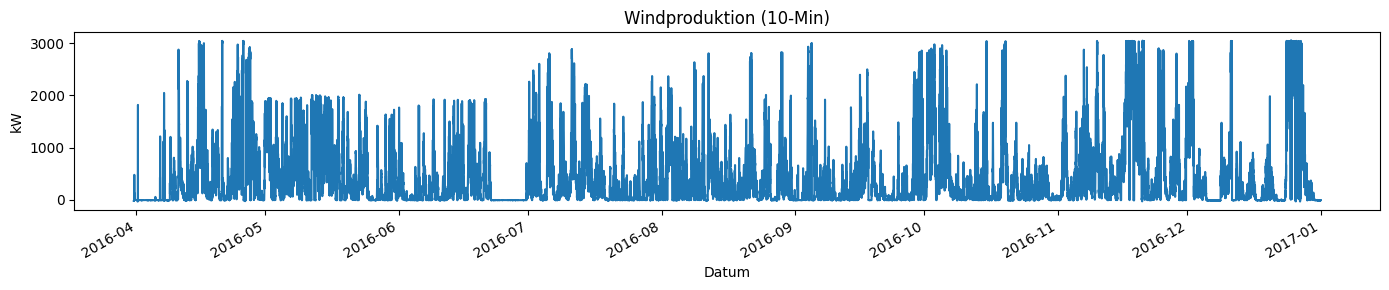

In [21]:
# TODO: Spaltennamen anpassen
PROD_COL = 'Leistung (Ø) [kW]'
WIND_COL  = 'Windgeschwindigkeit (Ø) [m/s]'
DATE_COL  = 'Datum'

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df.set_index(DATE_COL)[PROD_COL].plot(figsize=(14,3), title='Windproduktion (10-Min)')
plt.ylabel('kW')
plt.tight_layout()

## Verteilung Leistung

Text(0.5, 0, 'kW')

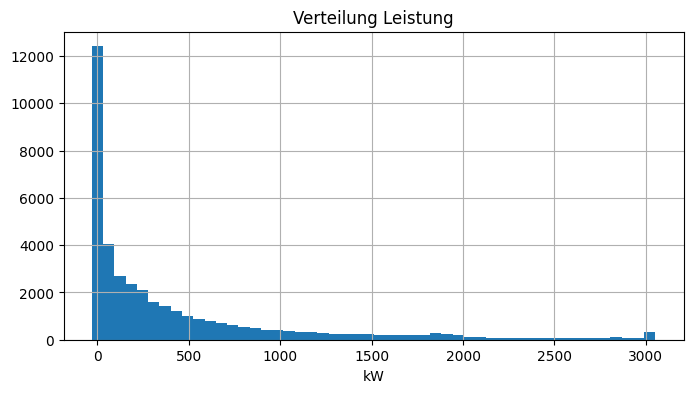

In [22]:
df[PROD_COL].hist(bins=50, figsize=(8,4))
plt.title('Verteilung Leistung')
plt.xlabel('kW')

## Wind Speed vs. Power (Power Curve)
Das ist die physikalische Beziehung – sollte eine S-Kurve sein.

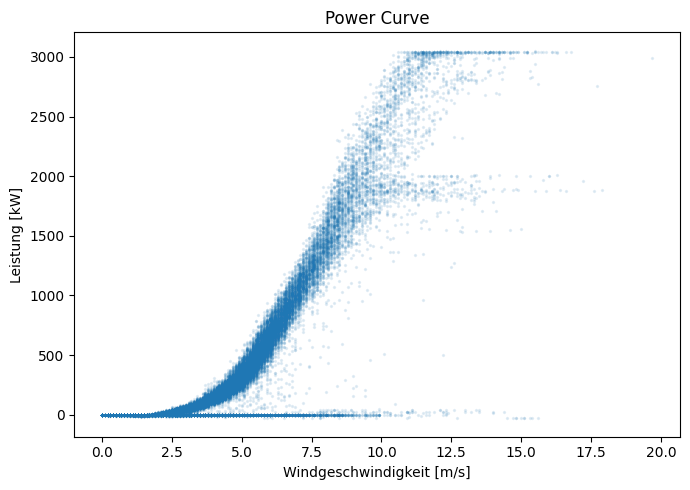

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(df[WIND_COL], df[PROD_COL], alpha=0.1, s=2)
plt.xlabel('Windgeschwindigkeit [m/s]')
plt.ylabel('Leistung [kW]')
plt.title('Power Curve')
plt.tight_layout()

## Saisonalität: Produktion nach Stunde
Gibt es Tagesverläufe?

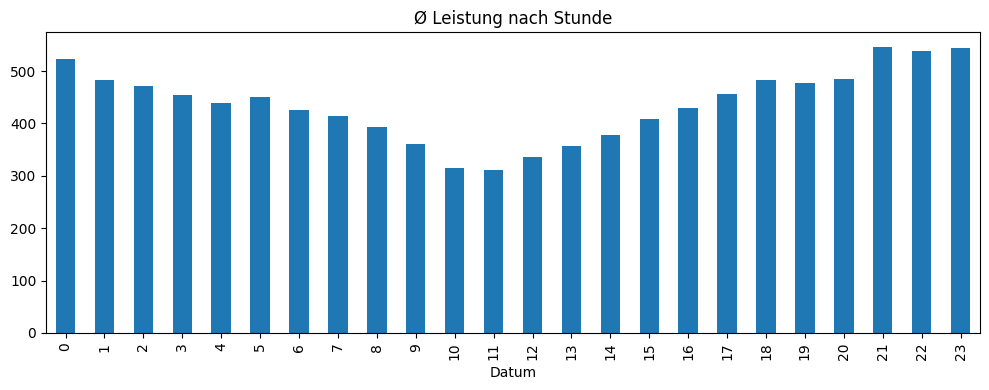

In [24]:
df['hour'] = df[DATE_COL].dt.hour if DATE_COL not in df.columns else pd.to_datetime(df.index).hour
# TODO: anpassen wenn Datum als Index
df.groupby(df[DATE_COL].dt.hour)[PROD_COL].mean().plot(kind='bar', figsize=(10,4), title='Ø Leistung nach Stunde')
plt.tight_layout()